In [5]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [22]:
import os
import json
import pandas as pd


results_dir = r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\simple_fine_tuning\results\mixed_generic\runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),


            "cxpb": h.get("cxpb"),
            "mutpb": h.get("mutpb"),
            "mutation_rate": h.get("mutation_rate"),
            "selector_mutation_rate": h.get("selector_mutation_rate"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,cxpb,mutpb,mutation_rate,selector_mutation_rate,popsize,generations,L_used,runtime_sec_meta
0,1,101,mixed_generic,438.65,43856.900,438.56900,87.719167,1797,False,1.50,0.003431,0.7725,0.230309,0.131924,0.179897,22,100,None,87.719167
1,1,202,mixed_generic,438.65,43843.175,438.43175,88.099969,1828,False,1.95,0.004465,0.7725,0.230309,0.131924,0.179897,22,100,None,88.099969
2,1,303,mixed_generic,438.65,43855.475,438.55475,87.954602,1840,False,1.95,0.004465,0.7725,0.230309,0.131924,0.179897,22,100,None,87.954602
3,1,404,mixed_generic,438.65,43859.075,438.59075,91.597979,1857,False,1.65,0.003776,0.7725,0.230309,0.131924,0.179897,22,100,None,91.597979
4,1,505,mixed_generic,438.65,43853.900,438.53900,87.825287,1848,False,1.50,0.003431,0.7725,0.230309,0.131924,0.179897,22,100,None,87.825287


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 493.947, p = 8.726e-54


In [3]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
75,929.681818,155.511137,11,379.181818
7,872.772727,181.287667,11,322.272727
92,872.545455,173.628260,11,322.045455
2,847.227273,241.378579,11,296.727273
56,839.181818,101.856584,11,288.681818
96,837.136364,213.256546,11,286.636364
73,831.500000,158.345508,11,281.000000
72,817.727273,193.950685,11,267.227273
25,798.318182,225.322577,11,247.818182


C:\Users\57305\AppData\Local\Temp\ipykernel_16964\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


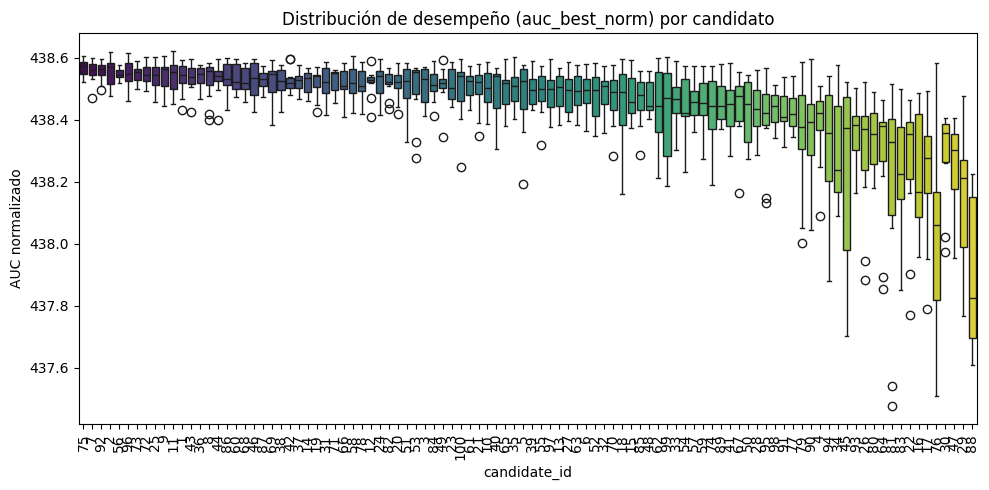

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,8 > 88,11,11,121.0,0.000040,0.199886,False
1,10 > 88,11,11,121.0,0.000041,0.200817,False
2,75 > 88,11,11,121.0,0.000041,0.200817,False
3,75 > 83,11,11,121.0,0.000041,0.200817,False
4,75 > 81,11,11,121.0,0.000041,0.200817,False
5,75 > 98,11,11,121.0,0.000041,0.200817,False
6,38 > 88,11,11,121.0,0.000041,0.200817,False
7,86 > 88,11,11,121.0,0.000041,0.200817,False
8,3 > 30,11,11,121.0,0.000041,0.200817,False
9,14 > 47,11,11,121.0,0.000041,0.200817,False


In [8]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [9]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)

,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,8 > 88,11,11,121.0,0.000040,0.199886,False
1,10 > 88,11,11,121.0,0.000041,0.200817,False
2,75 > 88,11,11,121.0,0.000041,0.200817,False
3,75 > 83,11,11,121.0,0.000041,0.200817,False
4,75 > 81,11,11,121.0,0.000041,0.200817,False
...,...,...,...,...,...,...,...
4945,64 > 75,11,11,0.0,0.999969,4949.847605,False
4946,30 > 86,11,11,0.0,0.999969,4949.847605,False
4947,30 > 73,11,11,0.0,0.999969,4949.847605,False
4948,4 > 75,11,11,0.0,0.999969,4949.847605,False


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


KeyboardInterrupt: 

In [10]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [11]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
2838,0,0,0
4133,0,0,0
4400,0,0,0
4947,0,0,0
5564,0,0,0
...,...,...,...
60009,0,0,0
60940,0,0,0
62686,0,0,0
62876,0,0,0


# Candidatos

In [11]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 75            438.567159  0.030468  438.550513
 56            438.548614  0.017006  438.539322
 92            438.554750  0.030819  438.537912
 7             438.554205  0.035165  438.534992
 73            438.547932  0.028259  438.532493
 72            438.546159  0.035983  438.526500
 96            438.549977  0.043807  438.526044
 2             438.551477  0.046953  438.525825
 25            438.541386  0.043810  438.517451
 36            438.534432  0.038287  438.513514,
 [75, 56, 92, 7, 73, 72, 96, 2, 25, 36])

In [12]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,75,36,11,60.0,0.006836,0.307617,False,0.307617,False
1,75,56,11,59.0,0.008789,0.386719,False,0.395508,False
2,75,25,11,58.0,0.012207,0.524902,False,0.549316,False
3,75,73,11,55.0,0.026855,1.000000,False,1.000000,False
4,92,36,11,54.5,0.028320,1.000000,False,1.000000,False
5,75,72,11,53.0,0.041504,1.000000,False,1.000000,False
6,75,7,11,52.0,0.048828,1.000000,False,1.000000,False
7,75,96,11,48.0,0.103027,1.000000,False,1.000000,False
8,92,72,11,47.0,0.115234,1.000000,False,1.000000,False
9,96,36,11,47.0,0.120117,1.000000,False,1.000000,False


In [13]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
2,0,0,0,0.0
7,0,0,0,0.0
25,0,0,0,0.0
36,0,0,0,0.0
56,0,0,0,0.0
72,0,0,0,0.0
73,0,0,0,0.0
75,0,0,0,0.0
92,0,0,0,0.0
96,0,0,0,0.0


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
75,438.567159,0.030468,11,0.009186,438.550509,438.52325
56,438.548614,0.017006,11,0.005128,438.539320,438.53450
92,438.554750,0.030819,11,0.009292,438.537908,438.50900
7,438.554205,0.035165,11,0.010603,438.534987,438.52925
73,438.547932,0.028259,11,0.008520,438.532489,438.52400
72,438.546159,0.035983,11,0.010849,438.526495,438.50225
96,438.549977,0.043807,11,0.013208,438.526038,438.51725
2,438.551477,0.046953,11,0.014157,438.525819,438.48275
25,438.541386,0.043810,11,0.013209,438.517445,438.50075


Shortlist: [75, 56, 92, 7, 73, 72, 96, 2, 25, 36]


In [15]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,75,36,11,60.0,0.006836,0.307617,False
1,75,56,11,59.0,0.008789,0.386719,False
2,75,25,11,58.0,0.012207,0.524902,False
3,75,73,11,55.0,0.026855,1.000000,False
4,92,36,11,54.5,0.028320,1.000000,False
5,75,72,11,53.0,0.041504,1.000000,False
6,75,7,11,52.0,0.048828,1.000000,False
7,75,96,11,48.0,0.103027,1.000000,False
8,92,72,11,47.0,0.115234,1.000000,False
9,96,36,11,47.0,0.120117,1.000000,False


,c1,c2,cliffs_delta
0,75,36,0.487603
1,75,56,0.388430
3,75,73,0.380165
2,75,25,0.371901
5,75,72,0.347107
12,7,36,0.347107
11,2,36,0.305785
7,75,96,0.305785
4,92,36,0.289256
13,75,92,0.264463


In [16]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
8,75,36,11,0.001465,0.973145,False
7,75,25,11,0.002441,0.973145,False
0,75,56,11,0.003418,0.875000,False
4,75,72,11,0.006836,0.839844,False
3,75,73,11,0.012207,0.767578,False
5,75,96,11,0.020996,0.817383,False
2,75,7,11,0.032227,0.787598,False
1,75,92,11,0.041504,0.517090,False
6,75,2,11,0.073730,0.649902,False


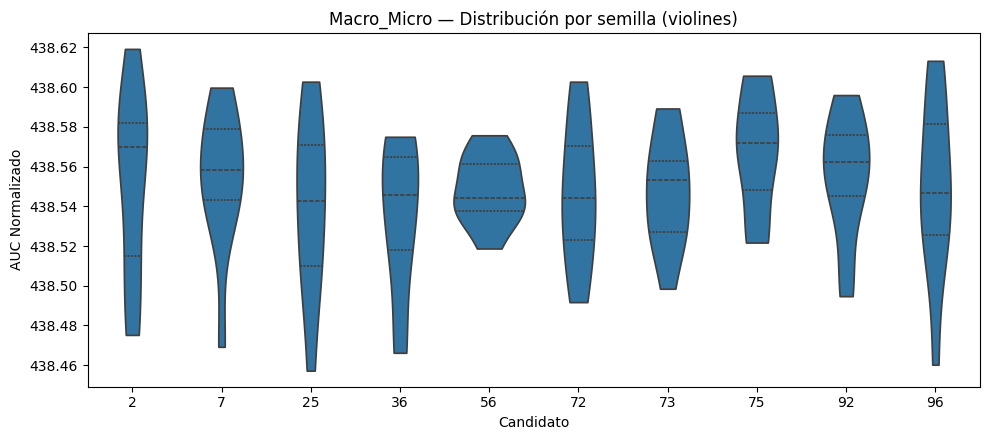

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [75, 56, 92, 7, 73, 72, 96, 2, 25, 36]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("Mixed generic— Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()

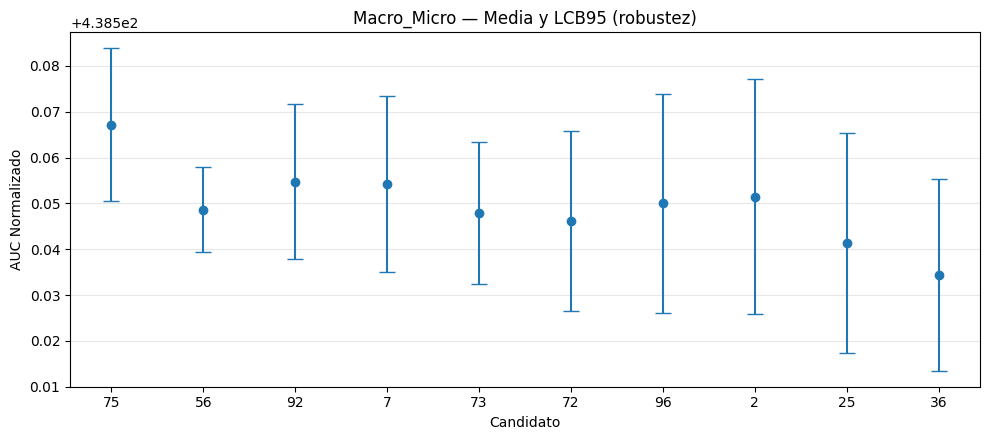

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("Mixed generic— Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

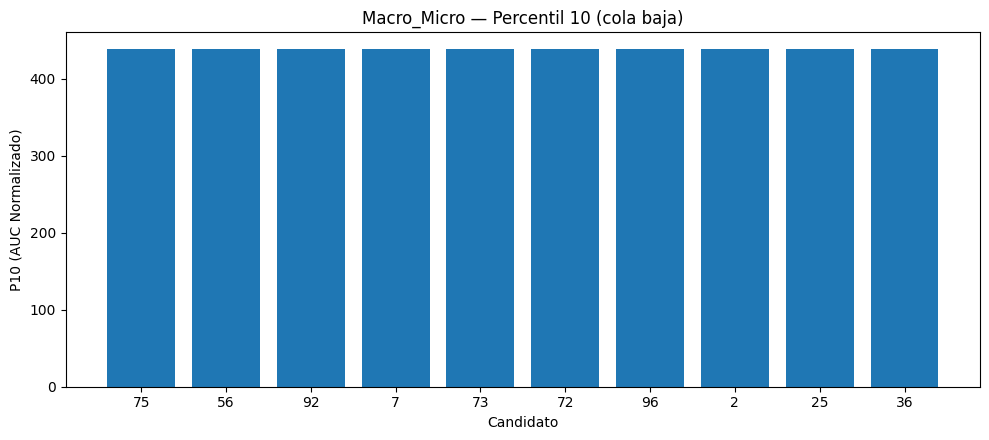

In [ ]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("Mixed generic — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [20]:
winner = 17925
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)

WINNER (robustez): 17925


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
75,438.567159,0.030468,11,0.009186,438.550509,438.52325
56,438.548614,0.017006,11,0.005128,438.539320,438.53450
92,438.554750,0.030819,11,0.009292,438.537908,438.50900
7,438.554205,0.035165,11,0.010603,438.534987,438.52925
73,438.547932,0.028259,11,0.008520,438.532489,438.52400
72,438.546159,0.035983,11,0.010849,438.526495,438.50225
96,438.549977,0.043807,11,0.013208,438.526038,438.51725
2,438.551477,0.046953,11,0.014157,438.525819,438.48275
25,438.541386,0.043810,11,0.013209,438.517445,438.50075


In [23]:
cid = 75

params_75 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["cxpb","mutpb", "mutation_rate", "selector_mutation_rate"]]
    .iloc[0]
)

params_75

cxpb                      0.731488
mutpb                     0.216271
mutation_rate             0.094761
selector_mutation_rate    0.095506
Name: 814, dtype: float64